<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/GoingDeeper/Gd03/Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ./aiffel/semantic_segmentation/data
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
!unzip data_semantics.zip -d ./aiffel/semantic_segmentation/data

--2026-09-03 01:38:30--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.121.22, 3.5.122.2, 3.5.120.40, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.121.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 327699796 (313M) [application/zip]
Saving to: ‘data_semantics.zip’

data_semantics.zip  100%[===================>] 312.52M  21.4MB/s    in 16s     

2026-09-03 01:38:46 (20.1 MB/s) - ‘data_semantics.zip’ saved [327699796/327699796]

Archive:  data_semantics.zip
   creating: ./aiffel/semantic_segmentation/data/testing/
   creating: ./aiffel/semantic_segmentation/data/testing/image_2/
  inflating: ./aiffel/semantic_segmentation/data/testing/image_2/000000_10.png  
  inflating: ./aiffel/semantic_segmentation/data/testing/image_2/000001_10.png  
  inflating: ./aiffel/semantic_segmentation/data/testing/image_2/000002_10.png  
  in

### 데이터 로더

In [2]:
!pip install albumentations

라이브러리 불러오기

In [3]:
import os
import math
import numpy as np
import PIL
import skimage
import torch
import torchvision.transforms as transforms
import matplotlib.font_manager as fm

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob

import albumentations
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

print(torch.__version__)
print(np.__version__)
print(PIL.__version__)
print(skimage.__version__)
print(albumentations.__version__)

2.11.0+cu128
2.1.3
11.3.0
0.25.2
2.0.8


In [27]:
# 한글 폰트 설치 및 설정
!apt-get -qq -y install fonts-nanum > /dev/null

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
def build_augmentation(is_train=True):
  if is_train:
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        # [검수] height/width 인자는 최신 albumentations(>=1.4)에서 제거되어
                        #        UserWarning 후 무시됩니다. crop 크기는 size로만 지정
                        min_max_height=(300, 370),
                        size=(224, 224),
                        w2h_ratio=370/1242,
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        height=224,
                        width=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행
                Resize(
                    height=224,
                    width=224
                    )
                ])

## Augmentation 적용 -> 원본이미지 / augment된 이미지

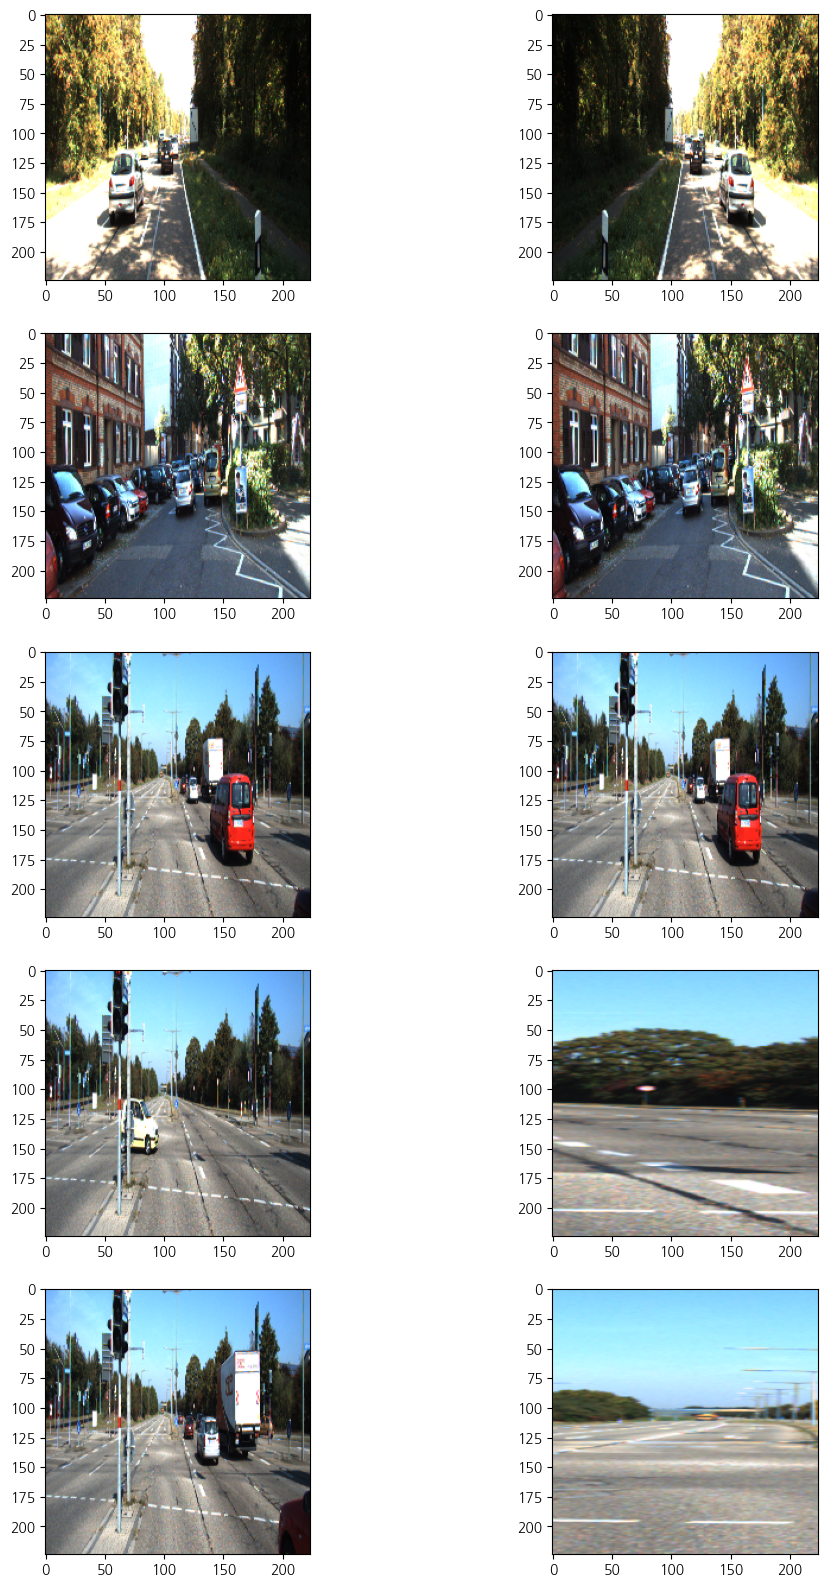

In [6]:
dir_path = "./aiffel/semantic_segmentation/data/training"

augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(dir_path, "image_2", "*.png"))

plt.figure(figsize=(12, 20))
for i in range(5):
    image = imread(input_images[i])
    image_data = {"image":image}
    resized = augmentation_test(**image_data)
    processed = augmentation_train(**image_data)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(resized["image"])
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(processed["image"])

plt.show()

## 데이터셋 구성

In [7]:
class KittiDataset(Dataset):

    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None):
        '''
        dir_path: dataset의 directory path
        img_size: preprocess에 사용할 입력이미지의 크기
        output_size: ground_truth를 만들어주기 위한 크기
        is_train: 이 Dataset이 학습용인지 테스트용인지 구분한다.
        augmentation: 적용하길 원하는 augmentation 함수를 인자로 받는다.
        '''
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size

        # load_dataset()을 통해 kitti dataset의 경로에서 라벨과 이미지를 확인
        self.data = self.load_dataset()

    def load_dataset(self):
        # kitti dataset에서 필요한 정보(이미지 경로 및 라벨)를 directory에서 확인하고 로드하는 함수
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        # Dataset의 length로서 전체 dataset 크기를 반환
        return len(self.data)

    def __getitem__(self, index):
        # 입력과 출력을 만듦
        # 입력: resize 및 augmentation이 적용된 input image /출력: semantic label
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)
        _output = imread(output_path)

        # 특정 라벨을 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # Normalize
            _output = augmented["mask"]

        # target 차원 확장 (H, W) → (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),  # (H, W, C) → (C, H, W)
            torch.tensor(_output, dtype=torch.float32)  # (1, H, W) 형식 유지
        )

    def shuffle_data(self):
        # 한 epoch가 끝나면 실행되는 함수다. 학습 중인 경우에 데이터를 random shuffle 한다.
        if self.is_train:
            np.random.shuffle(self.data)

In [8]:
# Augmentation 설정
augmentation = build_augmentation()
test_preproc = build_augmentation(is_train=False)

train_dataset = KittiDataset(
    dir_path,
    augmentation=augmentation,
    is_train=True
)

test_dataset = KittiDataset(
    dir_path,
    augmentation=test_preproc,
    is_train=False
)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## 시맨틱 세그멘테이션 모델



## 모델 구조 (U-Net)

In [9]:
class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # Expanding Path (Decoder)
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """2개의 Conv Layer로 이루어진 블록"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output
        output = torch.sigmoid(self.final(c9))
        return output

## 모델 학습

In [10]:
%%time

# 모델 저장 경로
model_path = "./aiffel/semantic_segmentation/seg_model_unet.pth"

# 모델 생성
model = UNet(input_channels=3, output_channels=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 손실 함수 및 옵티마이저 설정
criterion = torch.nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 데이터로더 준비
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 모델 학습
num_epochs = 100
train_losses = []   # epoch별 평균 loss를 기록해 학습 곡선
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets.float())  # 타겟을 float 타입으로 변환
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss}")

# 모델 저장
torch.save(model.state_dict(), model_path)

Epoch 1/100, Loss: 0.6790997169234536
Epoch 2/100, Loss: 0.6370129693638195
Epoch 3/100, Loss: 0.5804737372831865
Epoch 4/100, Loss: 0.5532318191094832
Epoch 5/100, Loss: 0.5054757622155276
Epoch 6/100, Loss: 0.3889029242775657
Epoch 7/100, Loss: 0.3590034679933028
Epoch 8/100, Loss: 0.3026310774413022
Epoch 9/100, Loss: 0.2811803424900228
Epoch 10/100, Loss: 0.25671526383269916
Epoch 11/100, Loss: 0.2354142354293303
Epoch 12/100, Loss: 0.23310118236325003
Epoch 13/100, Loss: 0.23268508233807303
Epoch 14/100, Loss: 0.23526094989343124
Epoch 15/100, Loss: 0.23185340789231387
Epoch 16/100, Loss: 0.203232926401225
Epoch 17/100, Loss: 0.19357418810779398
Epoch 18/100, Loss: 0.19085409289056604
Epoch 19/100, Loss: 0.20313258333639664
Epoch 20/100, Loss: 0.19447742673483762
Epoch 21/100, Loss: 0.18316500701687552
Epoch 22/100, Loss: 0.19079801711169156
Epoch 23/100, Loss: 0.1822985281998461
Epoch 24/100, Loss: 0.17093600806864825
Epoch 25/100, Loss: 0.17944530533118683
Epoch 26/100, Loss: 0.

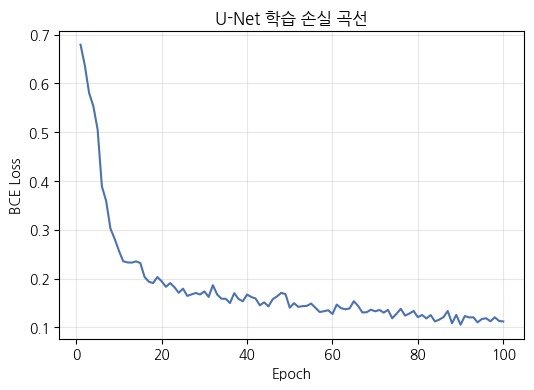

In [11]:
# U-Net 학습 손실(Loss) 곡선
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, color='#4C72B0')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('U-Net 학습 손실 곡선')
plt.grid(alpha=0.3)
plt.show()

## **20-4. 시맨틱 세그멘테이션 모델 시각화**

In [12]:
model = UNet(input_channels=3, output_channels=1)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()  # 평가 모드

UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc4): Sequential(
    (0): Con

## 시각화

In [13]:
def calculate_iou_score(target, prediction):
    if target.shape != prediction.shape:
        prediction = resize(prediction, target.shape, mode='constant', preserve_range=True).astype(np.uint8)

    intersection = np.logical_and(target, prediction).sum()
    union = np.logical_or(target, prediction).sum()
    iou_score = intersection / (union + 1e-7)
    print(f"IoU : {iou_score:.6f}")
    return iou_score

In [14]:
def get_output(model, preproc, image_path, output_path, label_path=None):
    origin_img = imread(image_path)
    data = {"image": origin_img}
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32)
    input_tensor = input_tensor.permute(2, 0, 1).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    prediction = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255
    prediction = Image.fromarray(prediction).convert('L')

    background = Image.fromarray(origin_img).convert('RGBA')
    prediction_resized = prediction.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(background, prediction_resized, alpha=0.5)

    blended.save(output_path)
    blended.show()

    target = None
    if label_path:
        label_img = imread(label_path)
        label_bin = (label_img == 7).astype(np.uint8)          # 먼저 도로 이진 마스크 생성
        target = preproc(image=origin_img, mask=label_bin)["mask"]   # mask는 nearest 보간

    return blended, np.array(prediction), target

In [15]:
# 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
output, prediction, target = get_output(
     model,
     test_preproc,
     image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
     output_path=dir_path + f'/result_{str(i).zfill(3)}.png',
     label_path=dir_path + f'/semantic/00{str(i).zfill(4)}_10.png'
 )

calculate_iou_score(target, prediction)

IoU : 0.898853


np.float64(0.8988525907995406)

## **프로젝트 : 개선된 U-Net 모델 만들기**

### **Step 1. KITTI 데이터셋 수집과 구축**

KITTI 데이터에 data augmentation을 적용한 형태로 데이터셋을 구축

In [16]:
BATCH_SIZE_UNETPP = 4

train_loader_pp = DataLoader(train_dataset, batch_size=BATCH_SIZE_UNETPP, shuffle=True)
test_loader_pp = DataLoader(test_dataset, batch_size=BATCH_SIZE_UNETPP, shuffle=False)

print(f"U-Net++ 학습용 batch_size: {BATCH_SIZE_UNETPP}")
print(f"학습 데이터: {len(train_dataset)}장 / 테스트 데이터: {len(test_dataset)}장")

U-Net++ 학습용 batch_size: 4
학습 데이터: 170장 / 테스트 데이터: 30장


### **Step 2. U-Net++ 모델의 구현**

In [17]:
# 아래 conv_block은 위 UNet.double_conv와 동일한 연산(Conv-ReLU-Conv-ReLU)이며,
# X^{i,j}마다 입력 채널 수가 다르므로(이전 단계 feature들을 모두 concat) 채널 수를
# 인자로 받는 함수 형태로 재사용합니다.

class UNetPlusPlus(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNetPlusPlus, self).__init__()
        nb_filter = [64, 128, 256, 512, 1024]   # U-Net과 동일한 채널 구성

        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.5)

        def conv_block(in_channels, out_channels):
            """2개의 Conv+ReLU로 이루어진 블록 (UNet.double_conv와 동일한 연산)."""
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
            )

        def up(in_channels, out_channels):
            return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

        # Encoder: X^{i,0} (i = 0..4)
        self.conv0_0 = conv_block(input_channels, nb_filter[0])
        self.conv1_0 = conv_block(nb_filter[0], nb_filter[1])
        self.conv2_0 = conv_block(nb_filter[1], nb_filter[2])
        self.conv3_0 = conv_block(nb_filter[2], nb_filter[3])
        self.conv4_0 = conv_block(nb_filter[3], nb_filter[4])   # bottleneck

        # Up-sampling: X^{i+1,*} -> X^{i,*}와 같은 해상도/채널로 변환
        self.up1_0 = up(nb_filter[1], nb_filter[0])
        self.up2_0 = up(nb_filter[2], nb_filter[1])
        self.up3_0 = up(nb_filter[3], nb_filter[2])
        self.up4_0 = up(nb_filter[4], nb_filter[3])

        self.up1_1 = up(nb_filter[1], nb_filter[0])
        self.up2_1 = up(nb_filter[2], nb_filter[1])
        self.up3_1 = up(nb_filter[3], nb_filter[2])

        self.up1_2 = up(nb_filter[1], nb_filter[0])
        self.up2_2 = up(nb_filter[2], nb_filter[1])

        self.up1_3 = up(nb_filter[1], nb_filter[0])

        # 중첩 skip pathway: X^{i,j} (j >= 1)
        # X^{i,j}의 입력 채널 = 그 행에서 이전에 만든 j개의 feature + 한 단계 아래에서 올라온 feature
        self.conv0_1 = conv_block(nb_filter[0] * 2, nb_filter[0])
        self.conv1_1 = conv_block(nb_filter[1] * 2, nb_filter[1])
        self.conv2_1 = conv_block(nb_filter[2] * 2, nb_filter[2])
        self.conv3_1 = conv_block(nb_filter[3] * 2, nb_filter[3])

        self.conv0_2 = conv_block(nb_filter[0] * 3, nb_filter[0])
        self.conv1_2 = conv_block(nb_filter[1] * 3, nb_filter[1])
        self.conv2_2 = conv_block(nb_filter[2] * 3, nb_filter[2])

        self.conv0_3 = conv_block(nb_filter[0] * 4, nb_filter[0])
        self.conv1_3 = conv_block(nb_filter[1] * 4, nb_filter[1])

        self.conv0_4 = conv_block(nb_filter[0] * 5, nb_filter[0])

        # 최종 출력은 U-Net과 동일하게 가장 정제된 최상단 해상도 feature에서 생성
        self.final = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)

    def forward(self, x):
        # j=0 (encoder)
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up1_0(x1_0)], dim=1))

        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up2_0(x2_0)], dim=1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up1_1(x1_1)], dim=1))

        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up3_0(x3_0)], dim=1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up2_1(x2_1)], dim=1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up1_2(x1_2)], dim=1))

        x4_0 = self.conv4_0(self.dropout(self.pool(x3_0)))     # bottleneck
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up4_0(x4_0)], dim=1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up3_1(x3_1)], dim=1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up2_2(x2_2)], dim=1))
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up1_3(x1_3)], dim=1))

        output = torch.sigmoid(self.final(x0_4))
        return output

print("U-Net++ 모델 정의 완료")

U-Net++ 모델 정의 완료


In [18]:
%%time

# U-Net++ 학습
model_path_pp = "./aiffel/semantic_segmentation/seg_model_unetpp.pth"

model_pp = UNetPlusPlus(input_channels=3, output_channels=1)
model_pp.to(device)

criterion_pp = torch.nn.BCELoss()
optimizer_pp = optim.Adam(model_pp.parameters(), lr=1e-4)

num_epochs_pp = 100
train_losses_pp = []   # epoch별 평균 loss를 기록해 학습 곡선 그림
for epoch in range(num_epochs_pp):
    model_pp.train()
    running_loss = 0.0
    for inputs, targets in train_loader_pp:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer_pp.zero_grad()
        outputs = model_pp(inputs)
        loss = criterion_pp(outputs, targets.float())
        loss.backward()
        optimizer_pp.step()

        running_loss += loss.item()

    epoch_loss_pp = running_loss / len(train_loader_pp)
    train_losses_pp.append(epoch_loss_pp)
    print(f"[U-Net++] Epoch {epoch+1}/{num_epochs_pp}, Loss: {epoch_loss_pp}")

torch.save(model_pp.state_dict(), model_path_pp)

[U-Net++] Epoch 1/100, Loss: 0.5902202108571696
[U-Net++] Epoch 2/100, Loss: 0.4802378669034603
[U-Net++] Epoch 3/100, Loss: 0.3712331434321958
[U-Net++] Epoch 4/100, Loss: 0.2858348623957745
[U-Net++] Epoch 5/100, Loss: 0.2619072105302367
[U-Net++] Epoch 6/100, Loss: 0.22216329498346463
[U-Net++] Epoch 7/100, Loss: 0.19186087732398233
[U-Net++] Epoch 8/100, Loss: 0.19763781754083412
[U-Net++] Epoch 9/100, Loss: 0.19322460924470147
[U-Net++] Epoch 10/100, Loss: 0.2193759983015615
[U-Net++] Epoch 11/100, Loss: 0.2417116369618926
[U-Net++] Epoch 12/100, Loss: 0.18918311665224474
[U-Net++] Epoch 13/100, Loss: 0.16597624088442603
[U-Net++] Epoch 14/100, Loss: 0.19171280673770016
[U-Net++] Epoch 15/100, Loss: 0.19649931875079177
[U-Net++] Epoch 16/100, Loss: 0.1826729680909667
[U-Net++] Epoch 17/100, Loss: 0.15719128417414288
[U-Net++] Epoch 18/100, Loss: 0.17557952656995418
[U-Net++] Epoch 19/100, Loss: 0.1707323377215585
[U-Net++] Epoch 20/100, Loss: 0.1616880067212637
[U-Net++] Epoch 21/

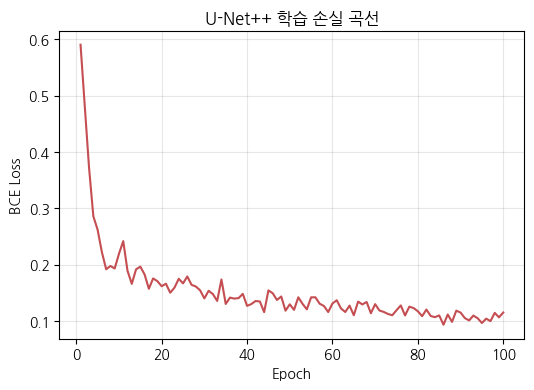

In [19]:
# U-Net++ 학습 손실(Loss) 곡선
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(train_losses_pp) + 1), train_losses_pp, color='#C44E52')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('U-Net++ 학습 손실 곡선')
plt.grid(alpha=0.3)
plt.show()

In [20]:
# 저장된 U-Net++ 가중치 로드
model_pp = UNetPlusPlus(input_channels=3, output_channels=1)
model_pp.load_state_dict(torch.load(model_path_pp, map_location=torch.device('cpu')))
model_pp.eval()

UNetPlusPlus(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (conv0_0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (conv1_0): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (conv2_0): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (conv3_0): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(5

In [21]:
# U-Net++ 결과를 먼저 눈으로 확인
i = 1
get_output(
    model_pp,
    test_preproc,
    image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
    output_path=dir_path + f'/result_unetpp_{str(i).zfill(3)}.png',
)

(<PIL.Image.Image image mode=RGBA size=1242x375>,
 array([[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0]], dtype=uint8),
 None)

### **Step 3. U-Net 과 U-Net++ 모델이 수행한 세그멘테이션 결과 분석**

In [22]:
# Step 3. U-Net과 U-Net++의 정량적/정성적 비교
# get_output(라벨 포함 버전)과 calculate_iou_score를 그대로 재사용해서,
# 같은 테스트 이미지들에 대해 두 모델의 시각화 결과 + IoU를 나란히 비교한다.
# 정성적 비교를 위해 오버레이 이미지도 함께 저장해 뒀다가 아래에서 한 번에 그린다.

model.eval()
model_pp.eval()

compare_indices = [1, 2, 3]   # 비교할 테스트 이미지 번호

unet_ious, unetpp_ious = [], []
overlay_unet_list, overlay_pp_list = [], []
origin_img_list, target_mask_list = [], []

for i in compare_indices:
    image_path = dir_path + f'/image_2/00{str(i).zfill(4)}_10.png'
    label_path = dir_path + f'/semantic/00{str(i).zfill(4)}_10.png'

    print(f"===== 이미지 {i} =====")
    print("--- U-Net ---")
    overlay_unet, pred_unet, target = get_output(
        model, test_preproc, image_path,
        output_path=dir_path + f'/result_unet_{str(i).zfill(3)}.png',
        label_path=label_path,
    )
    unet_ious.append(calculate_iou_score(target, pred_unet))

    print("--- U-Net++ ---")
    overlay_pp, pred_pp, target = get_output(
        model_pp, test_preproc, image_path,
        output_path=dir_path + f'/result_unetpp_{str(i).zfill(3)}.png',
        label_path=label_path,
    )
    unetpp_ious.append(calculate_iou_score(target, pred_pp))

    overlay_unet_list.append(overlay_unet)
    overlay_pp_list.append(overlay_pp)
    origin_img_list.append(imread(image_path))
    target_mask_list.append(target)

print("\n=== 평균 IoU 비교 ===")
print(f"U-Net   평균 IoU: {np.mean(unet_ious):.4f}")
print(f"U-Net++ 평균 IoU: {np.mean(unetpp_ious):.4f}")


===== 이미지 1 =====
--- U-Net ---
IoU : 0.898853
--- U-Net++ ---
IoU : 0.906778
===== 이미지 2 =====
--- U-Net ---
IoU : 0.689451
--- U-Net++ ---
IoU : 0.700091
===== 이미지 3 =====
--- U-Net ---
IoU : 0.749466
--- U-Net++ ---
IoU : 0.779243

=== 평균 IoU 비교 ===
U-Net   평균 IoU: 0.7793
U-Net++ 평균 IoU: 0.7954


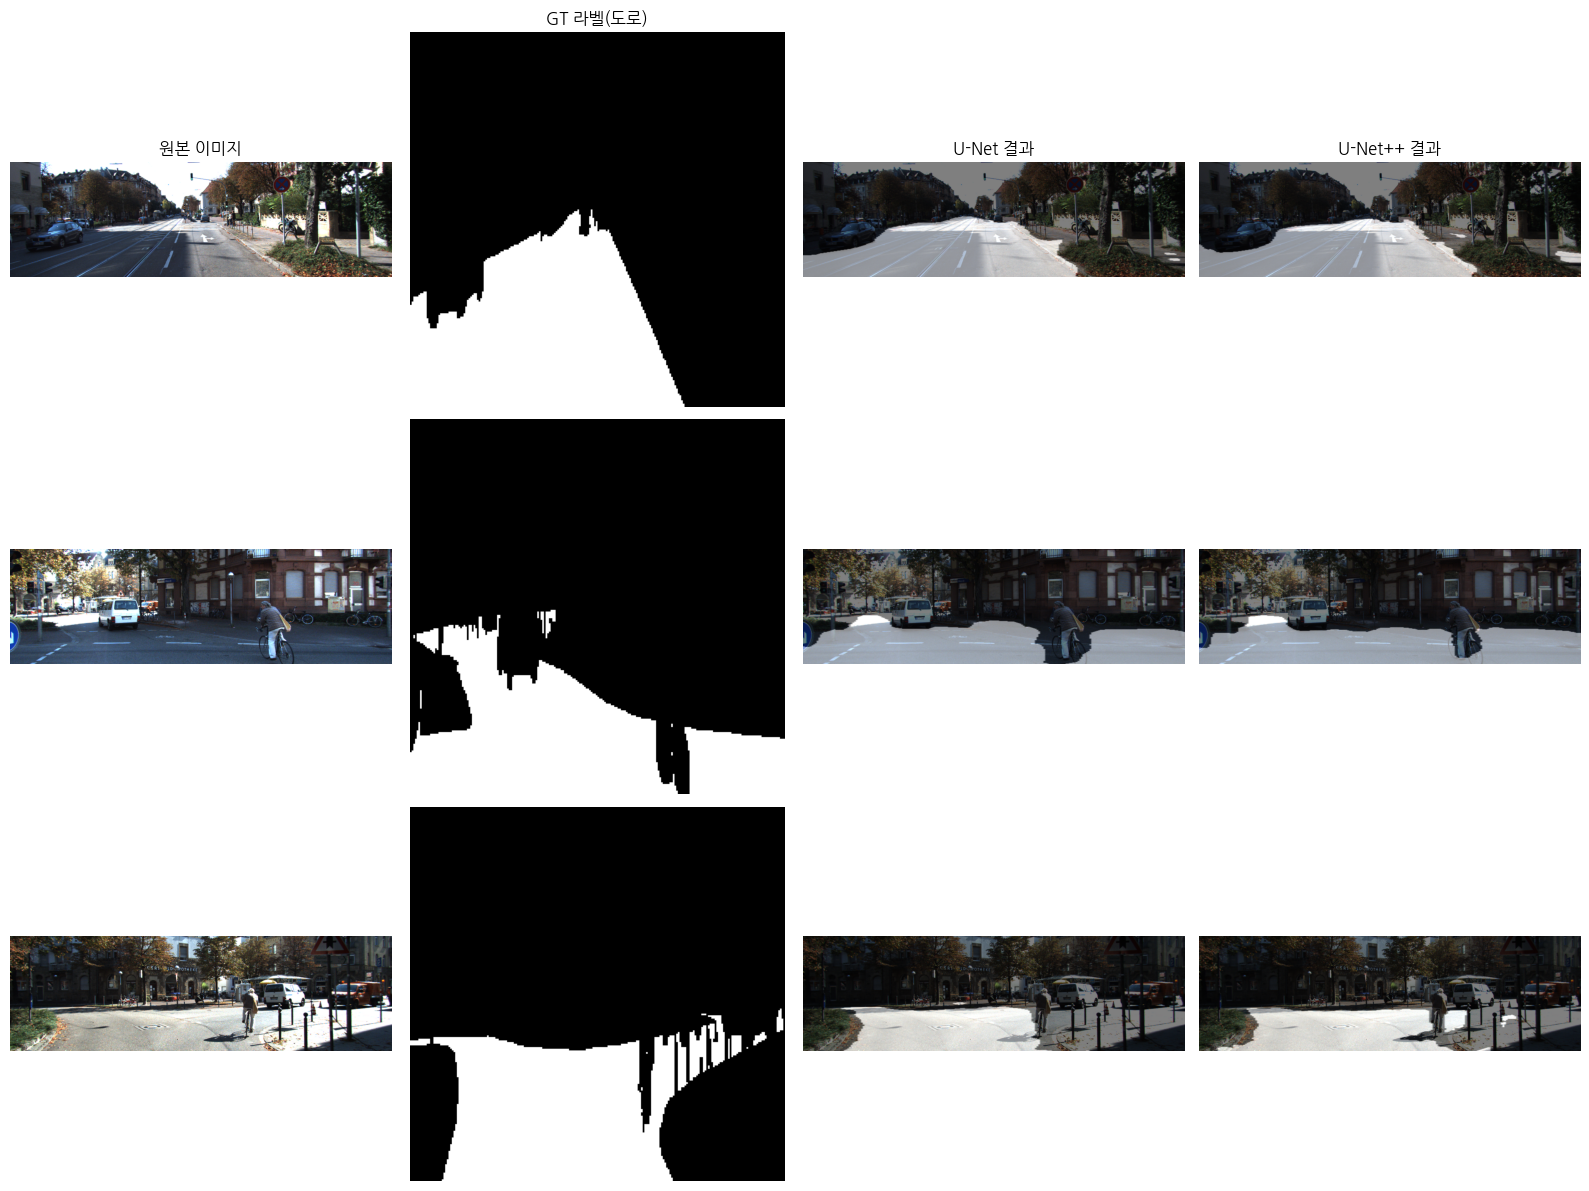

In [23]:
# 정성적 비교: 원본 / GT 라벨(도로 영역) / U-Net 오버레이 / U-Net++ 오버레이를
n = len(compare_indices)
fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
col_titles = ["원본 이미지", "GT 라벨(도로)", "U-Net 결과", "U-Net++ 결과"]

for row, i in enumerate(compare_indices):
    ax_row = axes[row] if n > 1 else axes
    ax_row[0].imshow(origin_img_list[row])
    ax_row[1].imshow(target_mask_list[row], cmap="gray")
    ax_row[2].imshow(overlay_unet_list[row])
    ax_row[3].imshow(overlay_pp_list[row])
    for col, ax in enumerate(ax_row):
        ax.axis("off")
        if row == 0:
            ax.set_title(col_titles[col])
    ax_row[0].set_ylabel(f"이미지 {i}", rotation=0, labelpad=40)

plt.tight_layout()
plt.show()


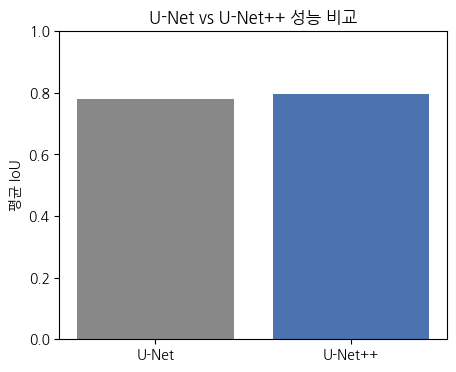

In [24]:
# 평균 IoU를 막대그래프로 비교
plt.figure(figsize=(5, 4))
plt.bar(['U-Net', 'U-Net++'], [np.mean(unet_ious), np.mean(unetpp_ious)],
        color=['#888888', '#4C72B0'])
plt.ylabel('평균 IoU')
plt.title('U-Net vs U-Net++ 성능 비교')
plt.ylim(0, 1)
plt.show()

## 시각화: 학습 곡선 비교 & 이미지별 IoU 비교

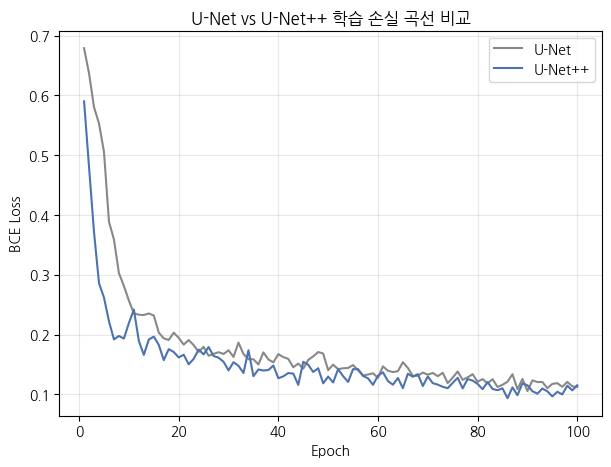

In [25]:
# U-Net vs U-Net++ 학습 손실(Loss) 곡선 비교
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='U-Net', color='#888888')
plt.plot(range(1, len(train_losses_pp) + 1), train_losses_pp, label='U-Net++', color='#4C72B0')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('U-Net vs U-Net++ 학습 손실 곡선 비교')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


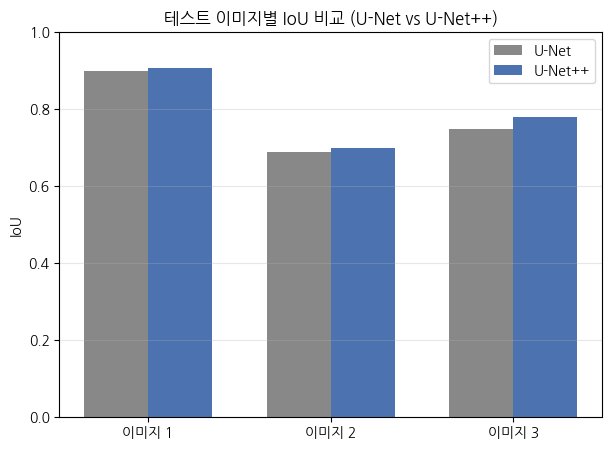

이미지 1: U-Net IoU=0.8989, U-Net++ IoU=0.9068, 개선폭=+0.0079
이미지 2: U-Net IoU=0.6895, U-Net++ IoU=0.7001, 개선폭=+0.0106
이미지 3: U-Net IoU=0.7495, U-Net++ IoU=0.7792, 개선폭=+0.0298


In [26]:
# 이미지별 IoU 비교
x = np.arange(len(compare_indices))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, unet_ious, width, label='U-Net', color='#888888')
plt.bar(x + width/2, unetpp_ious, width, label='U-Net++', color='#4C72B0')
plt.xticks(x, [f'이미지 {i}' for i in compare_indices])
plt.ylabel('IoU')
plt.ylim(0, 1)
plt.title('테스트 이미지별 IoU 비교 (U-Net vs U-Net++)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 이미지별 개선폭 표
for idx, i in enumerate(compare_indices):
    diff = unetpp_ious[idx] - unet_ious[idx]
    print(f"이미지 {i}: U-Net IoU={unet_ious[idx]:.4f}, U-Net++ IoU={unetpp_ious[idx]:.4f}, 개선폭={diff:+.4f}")
